In [1]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
PROJECT_ROOT = Path("../")

TRAIN_DIR = (
    PROJECT_ROOT /
    "data" /
    "raw" /
    "cifar10" /
    "cifar10"/"train"
)

classes = sorted(
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
)

In [4]:
pixel_values = []

for class_name in classes:

    for image_path in (TRAIN_DIR / class_name).glob("*"):

        image = cv2.imread(str(image_path))

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        pixel_values.append(image)

In [5]:
all_pixels = np.concatenate(
    [img.reshape(-1, 3) for img in pixel_values],
    axis=0
)

print(all_pixels.shape)

(51200000, 3)


In [6]:
mean_rgb = all_pixels.mean(axis=0)

print(mean_rgb)

[125.30691805 122.95039414 113.86538318]


In [7]:
std_rgb = all_pixels.std(axis=0)

print(std_rgb)

[62.99321928 62.08870764 66.70489964]


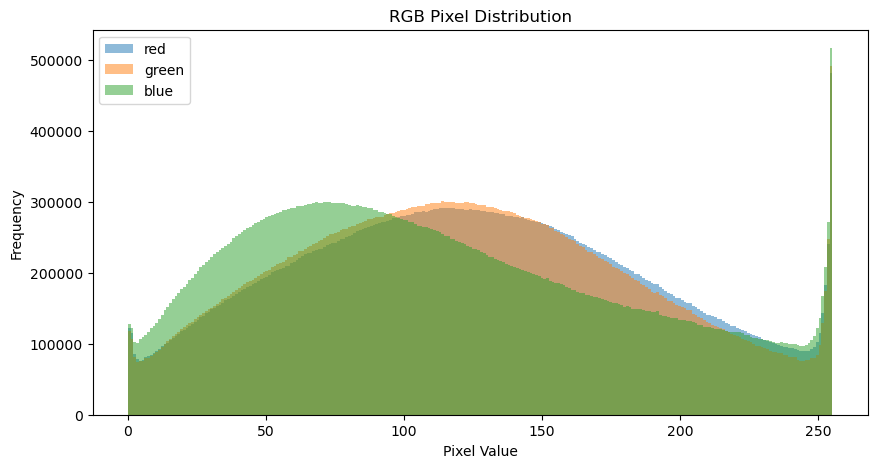

In [8]:
colors = ["red", "green", "blue"]

plt.figure(figsize=(10, 5))

for i, color in enumerate(colors):

    plt.hist(
        all_pixels[:, i],
        bins=256,
        alpha=0.5,
        label=color
    )

plt.legend()

plt.title("RGB Pixel Distribution")

plt.xlabel("Pixel Value")

plt.ylabel("Frequency")

plt.show()

In [9]:
brightness = []

for image in pixel_values:

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    brightness.append(gray.mean())

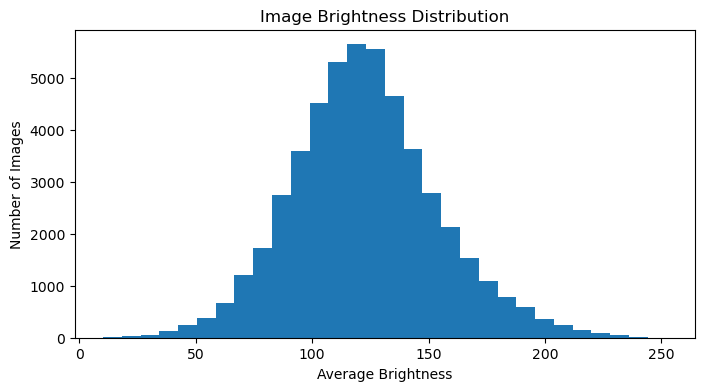

In [10]:
plt.figure(figsize=(8, 4))

plt.hist(brightness, bins=30)

plt.title("Image Brightness Distribution")

plt.xlabel("Average Brightness")

plt.ylabel("Number of Images")

plt.show()

In [11]:
contrast = []

for image in pixel_values:

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    contrast.append(gray.std())

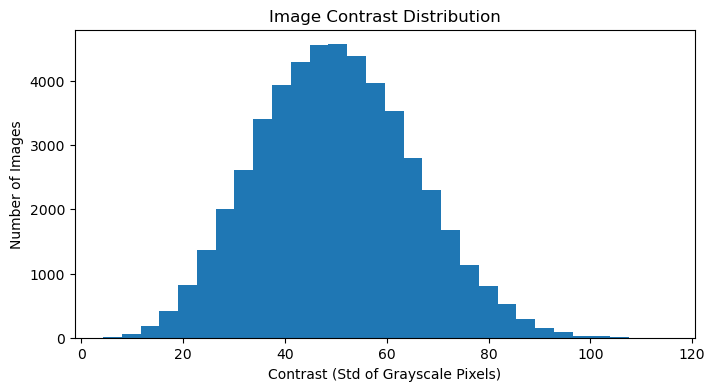

In [12]:
plt.figure(figsize=(8, 4))

plt.hist(contrast, bins=30)

plt.title("Image Contrast Distribution")

plt.xlabel("Contrast (Std of Grayscale Pixels)")

plt.ylabel("Number of Images")

plt.show()

In [13]:
summary = pd.DataFrame({
    "Statistic": [
        "Mean Red",
        "Mean Green",
        "Mean Blue",
        "Std Red",
        "Std Green",
        "Std Blue"
    ],
    "Value": [
        mean_rgb[0],
        mean_rgb[1],
        mean_rgb[2],
        std_rgb[0],
        std_rgb[1],
        std_rgb[2]
    ]
})

summary

,Statistic,Value
0,Mean Red,125.306918
1,Mean Green,122.950394
2,Mean Blue,113.865383
3,Std Red,62.993219
4,Std Green,62.088708
5,Std Blue,66.704900
